# Task 2: Machine Learning

## Team Members and Contributions

| Member | Name | Contribution | Individual Contribution Factor |
|---|---|---|---|
| 1 | Waralee Sridokmai | Dataset preprocessing and final review | 1.0 |
| 2 | Wanicha Srisukha | Deep Learning model | 1.0 |
| 3 | Ruethaimart Kongchuensin | Deep Learning evaluation and DL vs ML comparison | 1.0 |
| 4 | Peter Makropoulos | Machine Learning feature extraction | 1.0 |
| 5 | Nathakorn Wimonwatwethi | Machine Learning model training and hyperparameter tuning | 1.0 |
| 6 | Son Tung Tran | Machine Learning evaluation and appendix support | 1.0 |

## 0. Environment Setup

This section checks the required packages and imports the libraries used for the machine learning workflow.


In [3]:
# Install required packages.
import importlib
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "skimage": "scikit-image",
    "joblib": "joblib"
}

for module_name, package_name in required_packages.items():
    try:
        importlib.import_module(module_name)
        print(f"OK: {package_name} already installed")
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package_name]
        )

print("\nAll required packages are ready.")

OK: numpy already installed
OK: pandas already installed
OK: matplotlib already installed
OK: seaborn already installed
OK: scikit-learn already installed
OK: scikit-image already installed
OK: joblib already installed

All required packages are ready.


In [3]:
# Import all required libraries.

import os
import pickle
import tarfile
import time
import urllib.request
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from skimage.color import rgb2gray
from skimage.feature import hog

print("Environment setup completed successfully.")

Environment setup completed successfully.


## 1. Dataset Loading and Preprocessing

This section loads the CIFAR-10 dataset, checks the train/test split, shows sample images, normalises the image values, and prepares the labels for the next sections.

The same train/test split is used for both the deep learning and machine learning notebooks so the final comparison is fair.

### 1.1 Set Random Seed and Data Paths

In [4]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
DATA_DIR = Path("data")
ARCHIVE_PATH = DATA_DIR / "cifar-10-python.tar.gz"
EXTRACTED_DIR = DATA_DIR / "cifar-10-batches-py"

### 1.2 Download and Extract CIFAR-10

In [5]:
def download_cifar10():
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if EXTRACTED_DIR.exists():
        print("CIFAR-10 already extracted")
        return

    if not ARCHIVE_PATH.exists():
        print("Downloading CIFAR-10...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
        print("Download complete")

    print("Extracting CIFAR-10...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR, filter="data")

    print("Extraction complete")

download_cifar10()

CIFAR-10 already extracted


### 1.3 Load CIFAR-10 Data

In [6]:
def unpickle(file_path):
    with open(file_path, "rb") as file:
        data = pickle.load(file, encoding="latin1")
    return data

def load_cifar10():
    train_images = []
    train_labels = []

    for batch_number in range(1, 6):
        batch_path = EXTRACTED_DIR / f"data_batch_{batch_number}"
        batch = unpickle(batch_path)

        images = batch["data"]
        labels = batch["labels"]

        # CIFAR-10 stores each image as a flat array. Reshape it to 32 x 32 RGB format.
        images = images.reshape(-1, 3, 32, 32)
        images = images.transpose(0, 2, 3, 1)

        train_images.append(images)
        train_labels.append(labels)

    test_batch = unpickle(EXTRACTED_DIR / "test_batch")

    x_train = np.concatenate(train_images)
    y_train = np.concatenate(train_labels)

    x_test = test_batch["data"]
    y_test = np.array(test_batch["labels"])

    x_test = x_test.reshape(-1, 3, 32, 32)
    x_test = x_test.transpose(0, 2, 3, 1)

    meta = unpickle(EXTRACTED_DIR / "batches.meta")
    class_names = meta["label_names"]

    return x_train, y_train, x_test, y_test, class_names

x_train, y_train, x_test, y_test, class_names = load_cifar10()

print("CIFAR-10 data loaded")

CIFAR-10 data loaded


### 1.4 Check Dataset Information

In [7]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

print("\nNumber of classes:", len(class_names))
print("Class names:", class_names)

print("\nClass distribution:")
for class_id, class_name in enumerate(class_names):
    train_count = np.sum(y_train == class_id)
    test_count = np.sum(y_test == class_id)
    print(f"{class_name}: train={train_count}, test={test_count}")

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)

Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Class distribution:
airplane: train=5000, test=1000
automobile: train=5000, test=1000
bird: train=5000, test=1000
cat: train=5000, test=1000
deer: train=5000, test=1000
dog: train=5000, test=1000
frog: train=5000, test=1000
horse: train=5000, test=1000
ship: train=5000, test=1000
truck: train=5000, test=1000


### 1.5 Display Sample Images

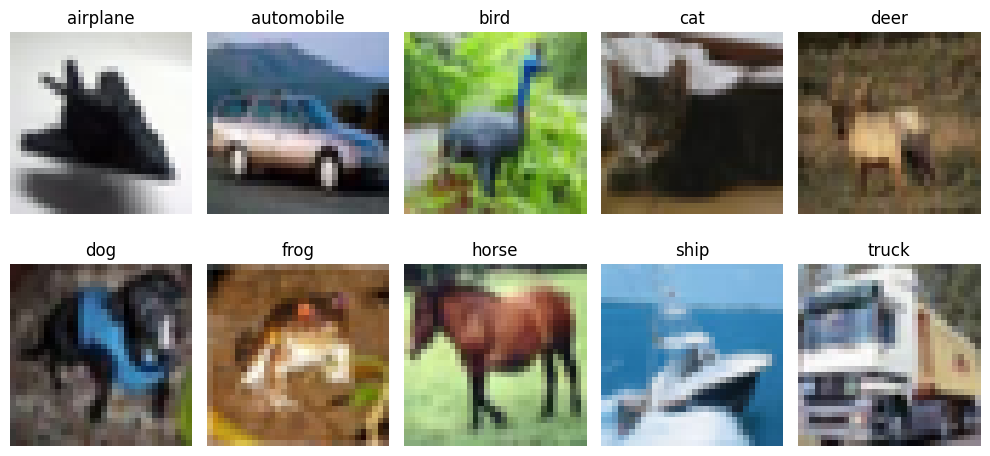

In [8]:
plt.figure(figsize=(10, 5))

for i in range(10):
    # Display one training image from each CIFAR-10 class.
    class_index = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[class_index], interpolation="nearest")
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

CIFAR-10 images are low resolution because each image is only 32 x 32 pixels.

### 1.6 Normalise Data for Machine Learning

In [9]:
# Normalise pixel values from 0-255 to 0-1 before feature extraction.
x_train_scaled = x_train.astype("float32") / 255.0
x_test_scaled = x_test.astype("float32") / 255.0

print("Training data min:", x_train_scaled.min())
print("Training data max:", x_train_scaled.max())
print("Testing data min:", x_test_scaled.min())
print("Testing data max:", x_test_scaled.max())

Training data min: 0.0
Training data max: 1.0
Testing data min: 0.0
Testing data max: 1.0


Normalizing the image data keeps pixel values on a smaller and consistent scale before feature extraction and model training.

### 1.7 Prepare Labels

In [10]:
y_train_ml = y_train.copy()
y_test_ml = y_test.copy()

print("Training labels shape:", y_train_ml.shape)
print("Testing labels shape:", y_test_ml.shape)
print("Example labels:", y_train_ml[:10])

Training labels shape: (50000,)
Testing labels shape: (10000,)
Example labels: [6 9 9 4 1 1 2 7 8 3]


### 1.8 Final Preprocessing Check

In [11]:
print("Final training data shape:", x_train_scaled.shape)
print("Final testing data shape:", x_test_scaled.shape)
print("Final training labels shape:", y_train_ml.shape)
print("Final testing labels shape:", y_test_ml.shape)

print("\nData type:", x_train_scaled.dtype)
print("Number of classes:", len(class_names))

assert x_train_scaled.shape == (50000, 32, 32, 3)
assert x_test_scaled.shape == (10000, 32, 32, 3)
assert y_train_ml.shape == (50000,)
assert y_test_ml.shape == (10000,)
assert x_train_scaled.min() >= 0 and x_train_scaled.max() <= 1
assert x_test_scaled.min() >= 0 and x_test_scaled.max() <= 1
assert len(class_names) == 10

print("Preprocessing check passed")

Final training data shape: (50000, 32, 32, 3)
Final testing data shape: (10000, 32, 32, 3)
Final training labels shape: (50000,)
Final testing labels shape: (10000,)

Data type: float32
Number of classes: 10
Preprocessing check passed


### 1.9 Prepared Data for Machine Learning

In [12]:
x_train_ml = x_train_scaled
x_test_ml = x_test_scaled

print("x_train_ml:", x_train_ml.shape)
print("x_test_ml:", x_test_ml.shape)
print("y_train_ml:", y_train_ml.shape)
print("y_test_ml:", y_test_ml.shape)

x_train_ml: (50000, 32, 32, 3)
x_test_ml: (10000, 32, 32, 3)
y_train_ml: (50000,)
y_test_ml: (10000,)


## 2. Feature Extraction

In [13]:
print("Feature extraction started...")

# Extract HOG features to represent image edge and shape information.
def get_hog_features(image):
    """Return HOG descriptors for one CIFAR-10 image."""
    if image.shape[-1] == 3:
        gray_img = rgb2gray(image)
    else:
        gray_img = image

    return hog(
        gray_img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )

# Extract colour histogram features from the RGB channels.
def get_color_histogram(image, bins=8):
    """Return an 8-bin colour histogram for each RGB channel."""
    rhist, _ = np.histogram(image[:, :, 0], bins=bins, range=(0, 1), density=True)
    ghist, _ = np.histogram(image[:, :, 1], bins=bins, range=(0, 1), density=True)
    bhist, _ = np.histogram(image[:, :, 2], bins=bins, range=(0, 1), density=True)

    return np.concatenate([rhist, ghist, bhist])

# Use the prepared ML image arrays from the preprocessing section.
print("Extracting HOG and colour histogram features...")

train_hog = np.array([get_hog_features(img) for img in x_train_ml])
test_hog = np.array([get_hog_features(img) for img in x_test_ml])

train_color = np.array([get_color_histogram(img) for img in x_train_ml])
test_color = np.array([get_color_histogram(img) for img in x_test_ml])

# Combine shape and colour features into one feature matrix.
X_train_raw_features = np.hstack((train_hog, train_color))
X_test_raw_features = np.hstack((test_hog, test_color))

# Standardise features using the training data only to avoid data leakage.
feature_scaler = StandardScaler()
X_train_features = feature_scaler.fit_transform(X_train_raw_features)
X_test_features = feature_scaler.transform(X_test_raw_features)

# Check that feature extraction preserves the original train/test split.
assert X_train_features.shape[0] == x_train_ml.shape[0] == y_train_ml.shape[0]
assert X_test_features.shape[0] == x_test_ml.shape[0] == y_test_ml.shape[0]
assert X_train_features.shape[1] == X_test_features.shape[1]

print("Feature extraction completed")
print(f"Training feature matrix: {X_train_features.shape}")
print(f"Testing feature matrix: {X_test_features.shape}")

Feature extraction started...
Extracting HOG and colour histogram features...
Feature extraction completed
Training feature matrix: (50000, 348)
Testing feature matrix: (10000, 348)


### 2.1 Hybrid Feature Engineering Pipeline

This section converts each CIFAR-10 image into a numeric feature vector for traditional machine learning models. The same training and testing arrays from preprocessing are used so that the final ML and DL comparison remains fair.

The feature vector combines HOG features and colour histogram features. HOG describes edge and shape information by converting each image to grayscale and measuring gradient orientation patterns. Colour histograms summarise the RGB colour distribution using 8 bins per channel.

After the features are combined, `StandardScaler` is fitted on the training features only and then applied to the testing features. This avoids data leakage because information from the test set is not used during scaling.

The final outputs for the next section are `X_train_features` and `X_test_features`, with 348 features per image.

## 3. Machine Learning Model and Hyperparameter Tuning

### 3.1 Problem Formulation

**Learning type:** supervised multi-class classification.  
The input is the extracted HOG and colour histogram features from CIFAR-10 images, and the output is one of the 10 CIFAR-10 classes.

In [14]:
# Prepare final feature and label variables for ML training.

X_train_ml = X_train_features
X_test_ml = X_test_features

y_train_ml = np.ravel(y_train)
y_test_ml = np.ravel(y_test)

print("Training feature matrix:", X_train_ml.shape)
print("Testing feature matrix:", X_test_ml.shape)
print("Training labels:", y_train_ml.shape)
print("Testing labels:", y_test_ml.shape)

Training feature matrix: (50000, 348)
Testing feature matrix: (10000, 348)
Training labels: (50000,)
Testing labels: (10000,)


### 3.2 Feature Set Used

The machine learning models use handcrafted image features.  
HOG captures shape and edge information, while colour histograms capture colour distribution.  
Combining both features provides a stronger representation than using raw pixels only.

In [15]:
feature_summary = pd.DataFrame({
    "Item": [
        "Training samples",
        "Testing samples",
        "Number of extracted features",
        "Classification classes"
    ],
    "Value": [
        X_train_ml.shape[0],
        X_test_ml.shape[0],
        X_train_ml.shape[1],
        len(np.unique(y_train_ml))
    ]
})

display(feature_summary)

,Item,Value
0,Training samples,50000
1,Testing samples,10000
2,Number of extracted features,348
3,Classification classes,10


### 3.3 Dataset Split Summary

The original CIFAR-10 training set is further divided into a training subset and a validation set.  
The validation set is used for hyperparameter tuning and model selection.  
The test set is kept unseen until the final evaluation.

Therefore, validation accuracy is used to choose the best ML model, and test accuracy is reported only after the selected model and hyperparameters are fixed.

In [16]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_ml,
    y_train_ml,
    test_size=0.1,
    random_state=42,
    stratify=y_train_ml
)

split_summary = pd.DataFrame({
    "Dataset": [
        "Training subset",
        "Validation set",
        "Test set"
    ],
    "Purpose": [
        "Model fitting",
        "Hyperparameter tuning and model selection",
        "Final unseen evaluation"
    ],
    "Samples": [
        len(X_train_sub),
        len(X_val),
        len(X_test_ml)
    ],
    "Feature dimensions": [
        X_train_sub.shape[1],
        X_val.shape[1],
        X_test_ml.shape[1]
    ]
})

display(split_summary)

,Dataset,Purpose,Samples,Feature dimensions
0,Training subset,Model fitting,45000,348
1,Validation set,Hyperparameter tuning and model selection,5000,348
2,Test set,Final unseen evaluation,10000,348


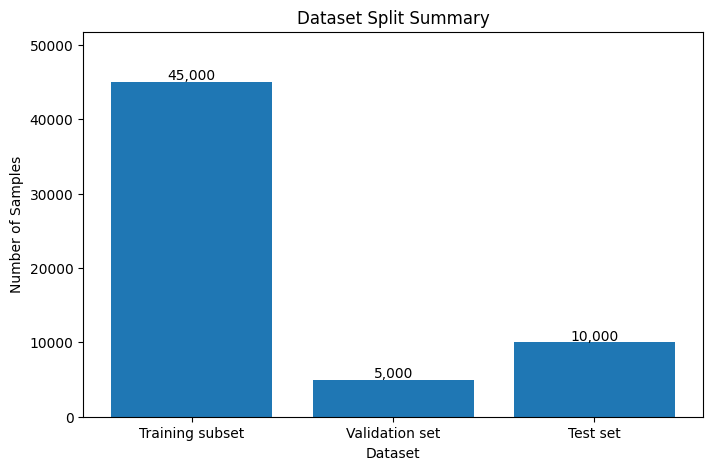

In [17]:
# Plot the training, validation, and test split sizes.

plt.figure(figsize=(8, 5))

bars = plt.bar(
    split_summary["Dataset"],
    split_summary["Samples"]
)

plt.title("Dataset Split Summary")
plt.xlabel("Dataset")
plt.ylabel("Number of Samples")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 300,
        f"{height:,}",
        ha="center"
    )

plt.ylim(0, max(split_summary["Samples"]) * 1.15)
plt.show()

,Class ID,Class Name,Training,Validation,Test
0,0,airplane,4500,500,1000
1,1,automobile,4500,500,1000
2,2,bird,4500,500,1000
3,3,cat,4500,500,1000
4,4,deer,4500,500,1000
5,5,dog,4500,500,1000
6,6,frog,4500,500,1000
7,7,horse,4500,500,1000
8,8,ship,4500,500,1000
9,9,truck,4500,500,1000


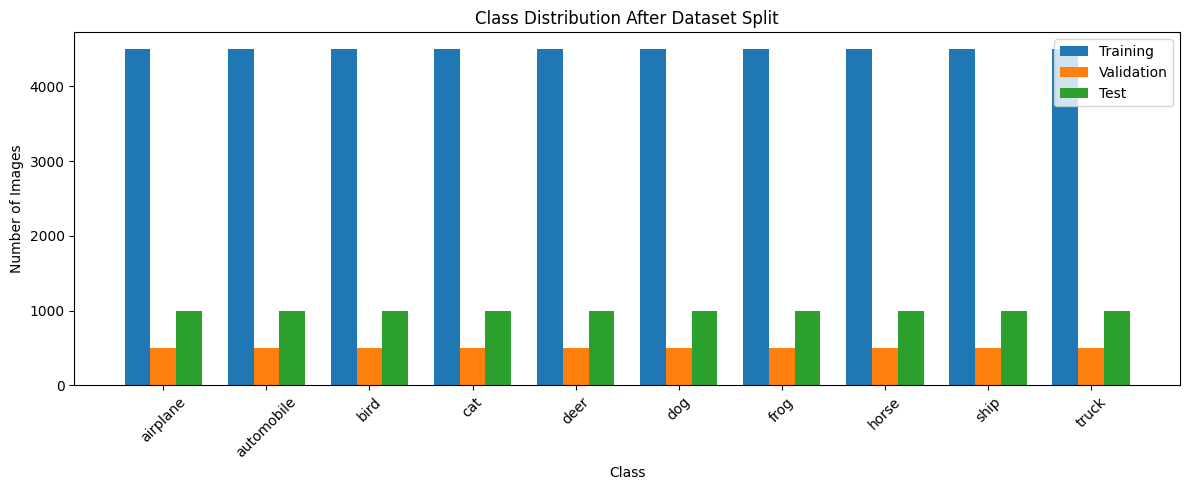

In [18]:
# Check whether each class is represented evenly after the split.

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

class_distribution = pd.DataFrame(
    {
        "Class ID": range(10),
        "Class Name": class_names,
        "Training": pd.Series(y_train_sub).value_counts().sort_index().values,
        "Validation": pd.Series(y_val).value_counts().sort_index().values,
        "Test": pd.Series(y_test_ml).value_counts().sort_index().values,
    }
)

display(class_distribution)

plt.figure(figsize=(12, 5))

x = np.arange(len(class_names))
width = 0.25

plt.bar(x - width, class_distribution["Training"], width, label="Training")
plt.bar(x, class_distribution["Validation"], width, label="Validation")
plt.bar(x + width, class_distribution["Test"], width, label="Test")

plt.title("Class Distribution After Dataset Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Model Selection

Three machine learning models are selected for comparison:

- SVM: a strong margin-based classifier, commonly effective with HOG features.
- Random Forest: an ensemble tree-based model used as a robust baseline.
- KNN: a simple distance-based classifier used as a comparison benchmark.

The best model is selected based on validation accuracy.

In [19]:
# Summarise the three ML models and the main tuned hyperparameters.

model_design = pd.DataFrame({
    "Model": [
        "SVM",
        "Random Forest",
        "KNN"
    ],
    "Model Type": [
        "Margin-based classifier",
        "Ensemble tree-based classifier",
        "Distance-based classifier"
    ],
    "Main Hyperparameter Tuned": [
        "C, kernel",
        "n_estimators, max_depth",
        "n_neighbors, weights"
    ],
    "Reason for Selection": [
        "Often performs well with HOG image features",
        "Good baseline and handles non-linear patterns",
        "Simple benchmark for feature similarity"
    ]
})

display(model_design)

,Model,Model Type,Main Hyperparameter Tuned,Reason for Selection
0,SVM,Margin-based classifier,"C, kernel",Often performs well with HOG image features
1,Random Forest,Ensemble tree-based classifier,"n_estimators, max_depth",Good baseline and handles non-linear patterns
2,KNN,Distance-based classifier,"n_neighbors, weights",Simple benchmark for feature similarity


### 3.5 Hyperparameter Tuning

Grid Search with 3-fold cross-validation is used to tune each model.  
Validation accuracy and training time are recorded to support model comparison.

In [20]:
# Train and tune the three candidate ML models using validation accuracy for selection.

models = {
    "SVM": {
        "model": SVC(),
        "params": {
            "C": [1, 10],
            "kernel": ["linear", "rbf"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [20, None]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        }
    }
}

tuning_results = []
best_models = {}

for model_name, model_info in models.items():
    print("=" * 60)
    print(f"Training model: {model_name}")

    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        scoring="accuracy",
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_sub, y_train_sub)

    training_time = time.time() - start_time

    best_model = grid_search.best_estimator_
    val_predictions = best_model.predict(X_val)

    val_accuracy = accuracy_score(y_val, val_predictions)

    best_models[model_name] = best_model

    tuning_results.append({
        "Model": model_name,
        "Best Parameters": grid_search.best_params_,
        "Best CV Accuracy": grid_search.best_score_,
        "Validation Accuracy": val_accuracy,
        "Training Time (seconds)": training_time
    })

    print("Best parameters:", grid_search.best_params_)
    print("Best CV accuracy:", round(grid_search.best_score_, 4))
    print("Validation accuracy:", round(val_accuracy, 4))
    print("Training time:", round(training_time, 2), "seconds")

Training model: SVM
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters: {'C': 10, 'kernel': 'rbf'}
Best CV accuracy: 0.6448
Validation accuracy: 0.6602
Training time: 3615.95 seconds
Training model: Random Forest
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters: {'max_depth': 20, 'n_estimators': 200}
Best CV accuracy: 0.5333
Validation accuracy: 0.539
Training time: 99.01 seconds
Training model: KNN
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'n_neighbors': 7, 'weights': 'uniform'}
Best CV accuracy: 0.5035
Validation accuracy: 0.52
Training time: 13.97 seconds


In [21]:
# Display the cross-validation, validation, and training-time results.

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df["Best CV Accuracy"] = tuning_results_df["Best CV Accuracy"].round(4)
tuning_results_df["Validation Accuracy"] = tuning_results_df["Validation Accuracy"].round(4)
tuning_results_df["Training Time (seconds)"] = tuning_results_df["Training Time (seconds)"].round(2)

display(tuning_results_df)

,Model,Best Parameters,Best CV Accuracy,Validation Accuracy,Training Time (seconds)
0,SVM,"{'C': 10, 'kernel': 'rbf'}",0.6448,0.6602,3615.95
1,Random Forest,"{'max_depth': 20, 'n_estimators': 200}",0.5333,0.5390,99.01
2,KNN,"{'n_neighbors': 7, 'weights': 'uniform'}",0.5035,0.5200,13.97


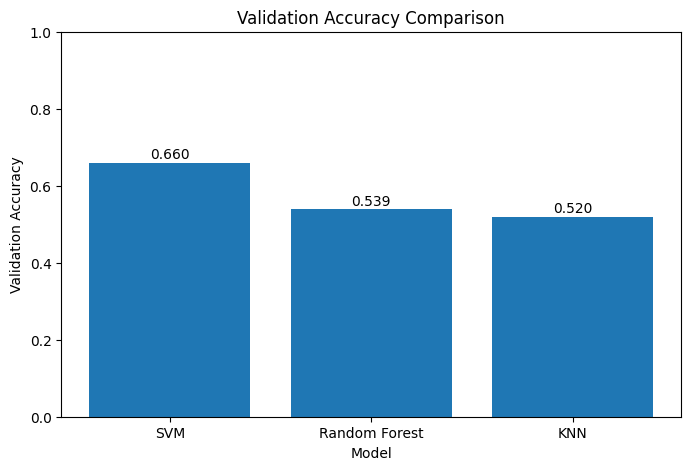

In [22]:
# Compare validation accuracy across the candidate ML models.

plt.figure(figsize=(8, 5))

bars = plt.bar(
    tuning_results_df["Model"],
    tuning_results_df["Validation Accuracy"]
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.show()

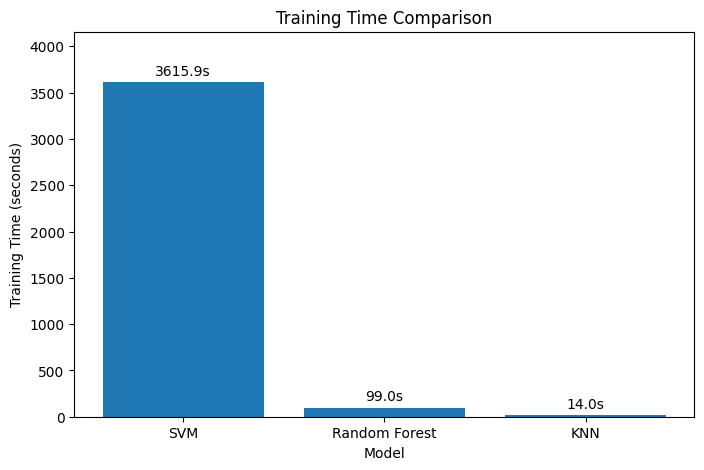

In [23]:
# Compare training time across the candidate ML models.

plt.figure(figsize=(8, 5))

bars = plt.bar(
    tuning_results_df["Model"],
    tuning_results_df["Training Time (seconds)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(tuning_results_df["Training Time (seconds)"]) * 0.02,
        f"{height:.1f}s",
        ha="center"
    )

plt.ylim(0, max(tuning_results_df["Training Time (seconds)"]) * 1.15)
plt.show()

### 3.6 Best Model Selection

The best machine learning model is selected based on validation accuracy.  
The selected model is then evaluated on the unseen CIFAR-10 test set.

In [24]:
# Select the best ML model using validation accuracy.

best_row = tuning_results_df.sort_values(
    "Validation Accuracy",
    ascending=False
).iloc[0]

best_model_name = best_row["Model"]
best_model = best_models[best_model_name]

print("Best ML model:", best_model_name)
print("Best validation accuracy:", best_row["Validation Accuracy"])
print("Best parameters:", best_row["Best Parameters"])

Best ML model: SVM
Best validation accuracy: 0.6602
Best parameters: {'C': 10, 'kernel': 'rbf'}


### 3.7 Test Set Evaluation

The selected model is applied to the unseen test set.  
Accuracy, classification report, and confusion matrix are used to evaluate the final performance.

In [25]:
# Evaluate the selected ML model on the held-out test set.

y_pred_test = best_model.predict(X_test_ml)

test_accuracy = accuracy_score(y_test_ml, y_pred_test)

print("Best model:", best_model_name)
print("Test accuracy:", round(test_accuracy, 4))

Best model: SVM
Test accuracy: 0.6613


In [26]:
# Generate precision, recall, F1-score, and accuracy metrics.

report = classification_report(
    y_test_ml,
    y_pred_test,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df.round(4))

,precision,recall,f1-score,support
airplane,0.6905,0.7720,0.7290,1000.0000
automobile,0.7794,0.8090,0.7939,1000.0000
bird,0.5701,0.5530,0.5614,1000.0000
cat,0.4645,0.4710,0.4677,1000.0000
deer,0.5921,0.5820,0.5870,1000.0000
dog,0.5516,0.5450,0.5483,1000.0000
frog,0.7200,0.7330,0.7265,1000.0000
horse,0.7361,0.6640,0.6982,1000.0000
ship,0.7344,0.7300,0.7322,1000.0000
truck,0.7733,0.7540,0.7635,1000.0000


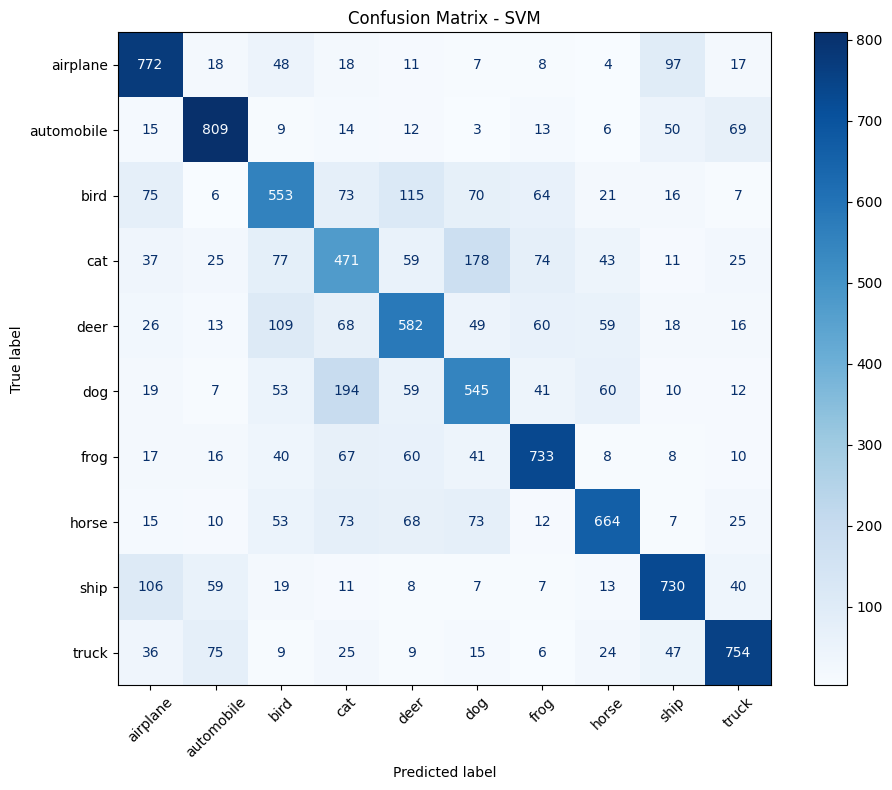

In [27]:
OUTPUT_DIR = "ml_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Generate and save the final confusion matrix.
cm = confusion_matrix(y_test_ml, y_pred_test)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

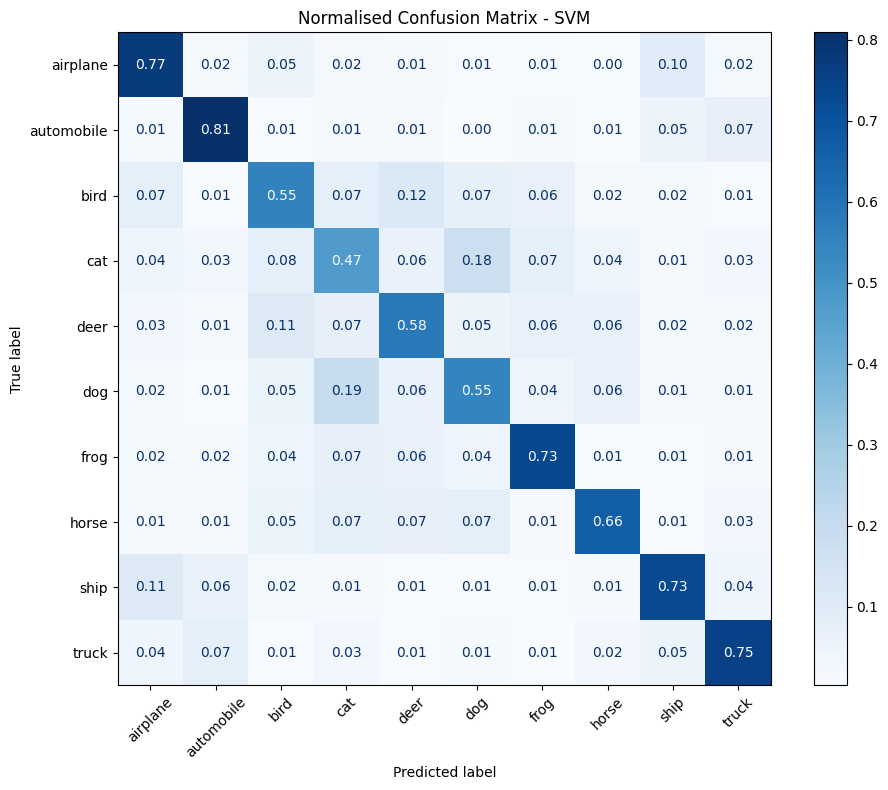

In [28]:
# Plot the normalised confusion matrix to compare per-class performance.

cm_normalised = confusion_matrix(
    y_test_ml,
    y_pred_test,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalised,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title(f"Normalised Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

### 3.8 Prediction Examples and Error Analysis

Sample test images are displayed with their true labels and predicted labels.  
This helps visually inspect how the machine learning model performs on real CIFAR-10 images.

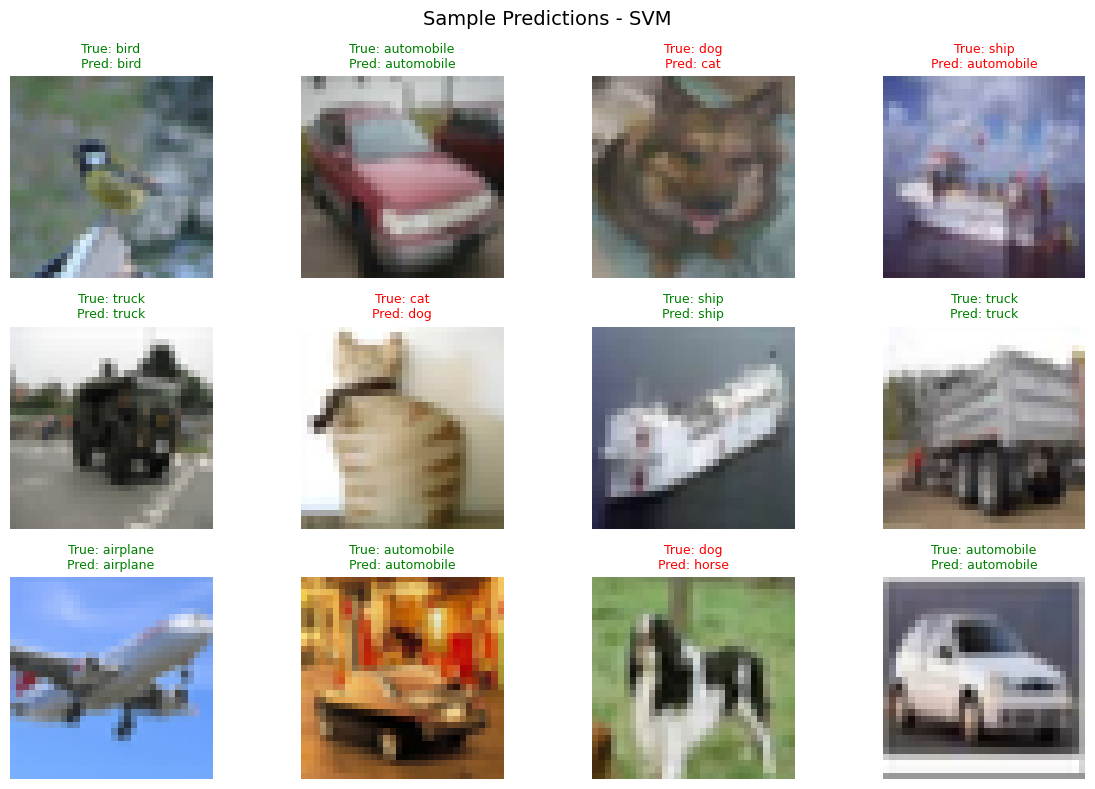

In [29]:
# Display a random sample of test predictions.

test_images_for_display = x_test

sample_indices = np.random.choice(
    len(test_images_for_display),
    size=12,
    replace=False
)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(sample_indices):
    plt.subplot(3, 4, i + 1)

    image = test_images_for_display[idx]

    plt.imshow(image)

    true_label = class_names[y_test_ml[idx]]
    pred_label = class_names[y_pred_test[idx]]

    title_color = "green" if true_label == pred_label else "red"

    plt.title(
        f"True: {true_label}\nPred: {pred_label}",
        color=title_color,
        fontsize=9
    )

    plt.axis("off")

plt.suptitle(f"Sample Predictions - {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

Number of misclassified images: 3387
Total test images: 10000


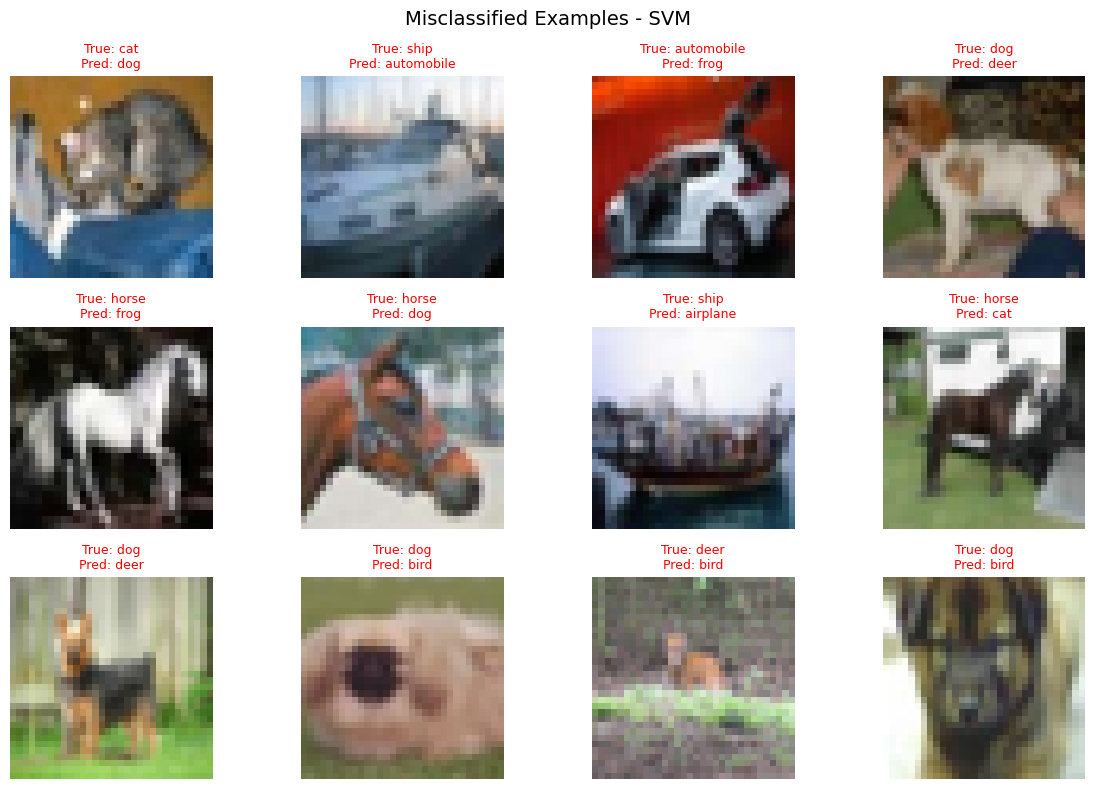

In [30]:
# Display examples where the selected model made incorrect predictions.

incorrect_indices = np.where(y_pred_test != y_test_ml)[0]

print("Number of misclassified images:", len(incorrect_indices))
print("Total test images:", len(y_test_ml))

if len(incorrect_indices) > 0:
    selected_incorrect = incorrect_indices[:12]

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(selected_incorrect):
        plt.subplot(3, 4, i + 1)

        image = test_images_for_display[idx]
        plt.imshow(image)

        true_label = class_names[y_test_ml[idx]]
        pred_label = class_names[y_pred_test[idx]]

        plt.title(
            f"True: {true_label}\nPred: {pred_label}",
            color="red",
            fontsize=9
        )

        plt.axis("off")

    plt.suptitle(f"Misclassified Examples - {best_model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [31]:
# Calculate correct and incorrect predictions for each CIFAR-10 class.

error_analysis = []

for class_id, class_name in enumerate(class_names):
    class_mask = y_test_ml == class_id
    class_total = np.sum(class_mask)
    class_correct = np.sum(y_pred_test[class_mask] == y_test_ml[class_mask])
    class_incorrect = class_total - class_correct
    class_accuracy = class_correct / class_total

    error_analysis.append({
        "Class": class_name,
        "Total": class_total,
        "Correct": class_correct,
        "Incorrect": class_incorrect,
        "Class Accuracy": class_accuracy
    })

error_analysis_df = pd.DataFrame(error_analysis)
error_analysis_df["Class Accuracy"] = error_analysis_df["Class Accuracy"].round(4)

display(error_analysis_df)

,Class,Total,Correct,Incorrect,Class Accuracy
0,airplane,1000,772,228,0.772
1,automobile,1000,809,191,0.809
2,bird,1000,553,447,0.553
3,cat,1000,471,529,0.471
4,deer,1000,582,418,0.582
5,dog,1000,545,455,0.545
6,frog,1000,733,267,0.733
7,horse,1000,664,336,0.664
8,ship,1000,730,270,0.730
9,truck,1000,754,246,0.754


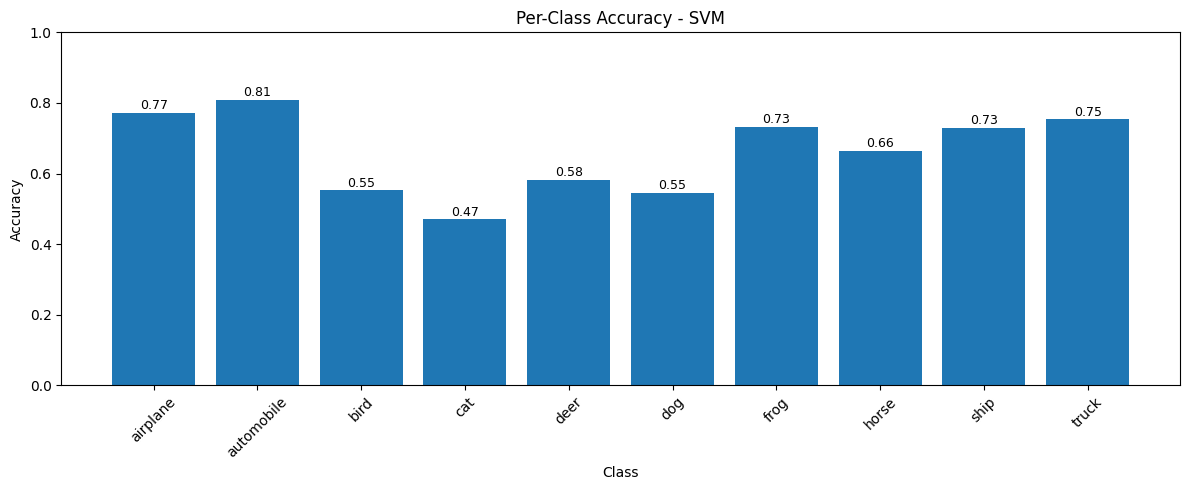

In [32]:
# Plot test accuracy for each CIFAR-10 class.

plt.figure(figsize=(12, 5))

bars = plt.bar(
    error_analysis_df["Class"],
    error_analysis_df["Class Accuracy"]
)

plt.title(f"Per-Class Accuracy - {best_model_name}")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [33]:
# Create a concise summary for the appendix and presentation.

final_summary = pd.DataFrame({
    "Selected ML Model": [best_model_name],
    "Validation Accuracy": [best_row["Validation Accuracy"]],
    "Test Accuracy": [round(test_accuracy, 4)],
    "Feature Method": ["HOG + Colour Histogram"],
    "Purpose": ["Traditional ML comparison with DL model"]
})

display(final_summary)

,Selected ML Model,Validation Accuracy,Test Accuracy,Feature Method,Purpose
0,SVM,0.6602,0.6613,HOG + Colour Histogram,Traditional ML comparison with DL model


In [34]:
# Save the selected model and summary files for the appendix/final submission.

OUTPUT_DIR = "ml_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(
    best_model,
    os.path.join(OUTPUT_DIR, "best_ml_model.pkl")
)

tuning_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "ml_tuning_results.csv"),
    index=False
)

final_summary.to_csv(
    os.path.join(OUTPUT_DIR, "ml_final_summary.csv"),
    index=False
)

print("Essential ML outputs saved successfully.")

Essential ML outputs saved successfully.


### 3.9 Machine Learning Summary

Three traditional machine learning models (SVM, Random Forest, and KNN) were trained and evaluated using HOG and colour histogram features extracted from the CIFAR-10 dataset.

Hyperparameter tuning was performed using GridSearchCV with 3-fold cross-validation. Among the evaluated models, SVM achieved the best performance, obtaining a validation accuracy of 66.02% and a final test accuracy of 66.13%.

The confusion matrix and class-level evaluation indicate that some object categories were classified more accurately than others, while the misclassified examples highlight the limitations of handcrafted features when distinguishing visually similar classes.

Overall, the results demonstrate that traditional machine learning methods can achieve reasonable performance when combined with effective feature engineering. These findings provide a strong baseline for comparison with the deep learning approach, which learns image features automatically from raw pixel data.